In [1]:
#clustering notebook - mall segmentation
#importation of libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
data=pd.read_csv("C:/Users/ADMIN/Downloads/archive (4).zip")   #Loading of the dataset
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
data.rename(columns={'Annual Income (k$)':'Annual Income (sh 10000)'},inplace=True)
data.head()

,CustomerID,Gender,Age,Annual Income (sh 10000),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data3=data.drop(columns=["CustomerID","Gender"],inplace=False)
data3.head()

,Age,Annual Income (sh 10000),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [5]:
data3.describe()

,Age,Annual Income (sh 10000),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [6]:
#Step3 Standardise data
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data3)

In [7]:
scaled_data

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [9]:
#Apply KMeans clustering
kmeans=KMeans(n_clusters=3,random_state=42)
data3["Cluster"]=kmeans.fit_predict(scaled_data)

In [13]:
data3

,Age,Annual Income (sh 10000),Spending Score (1-100),Cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,2
3,23,16,77,2
4,31,17,40,2
...,...,...,...,...
195,35,120,79,1
196,45,126,28,0
197,32,126,74,1
198,32,137,18,1


In [14]:
data.Cluster.unique()

array([2, 0, 1], dtype=int32)

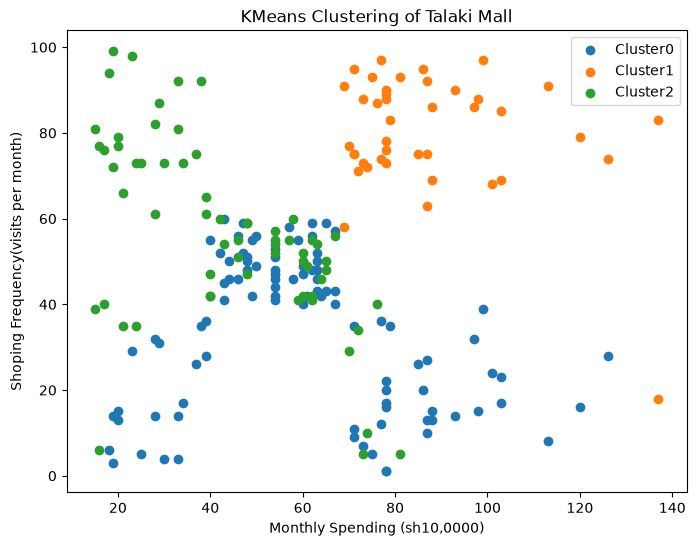

In [16]:
#Visualize the clusters
plt.figure(figsize=(8,6))
for cluster in range(3):
    clustered_points=data[data3["Cluster"]==cluster]
    plt.scatter(clustered_points["Annual Income (sh 10000)"],
                clustered_points["Spending Score (1-100)"],
                label=f"Cluster{cluster}")
plt.xlabel("Monthly Spending (sh10,0000)")
plt.ylabel("Shoping Frequency(visits per month)")
plt.title("KMeans Clustering of Talaki Mall")
plt.legend()
plt.show()

In [17]:
print(data3.head(10))

   Age  Annual Income (sh 10000)  Spending Score (1-100)  Cluster
0   19                        15                      39        2
1   21                        15                      81        2
2   20                        16                       6        2
3   23                        16                      77        2
4   31                        17                      40        2
5   22                        17                      76        2
6   35                        18                       6        0
7   23                        18                      94        2
8   64                        19                       3        0
9   30                        19                      72        2
